# I. Importing The necessary packages for the modelling

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# II. Investigating the Data thoroughly

In [3]:
df = pd.read_csv('data_science_job.csv')
df

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer in office,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician (Remote),ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst in office,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer (Remote),NaN,NaN,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer (Remote),NaN,NaN,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


In [9]:
for column in df.columns:
    print (f'------------------------ {column} ------------------------')
    print (df[column].unique())

------------------------ work_year ------------------------
[2022 2020 2021]
------------------------ job_title ------------------------
['Machine Learning Engineer  in office' 'Statistician  (Remote)'
 'Machine Learning Engineer  ' 'Data Analyst  in office' 'Statistician  '
 'Data Scientist  (Remote)' 'Data Analyst  ' 'Data Engineer  in office'
 'Data Scientist  ' 'Machine Learning Engineer  (Remote)'
 'Data Engineer  ' 'Data Engineer  (Remote)' 'Data Scientist  in office'
 'Data Analyst  (Remote)' 'Statistician  in office']
------------------------ job_category ------------------------
['Analysis' 'ML/AI' 'Data Science' 'Engineering' nan]
------------------------ salary_currency ------------------------
['EUR' 'JPY' 'INR' nan 'us dolars' 'GBP']
------------------------ salary ------------------------
[186597 110630  61280 ... 135319  58037 143565]
------------------------ salary_in_usd ------------------------
[136086  67982 153309 ...  51366 181817 172425]
------------------------ e

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           5000 non-null   int64 
 1   job_title           5000 non-null   object
 2   job_category        4500 non-null   object
 3   salary_currency     4500 non-null   object
 4   salary              5000 non-null   int64 
 5   salary_in_usd       5000 non-null   int64 
 6   employee_residence  5000 non-null   object
 7   experience_level    4500 non-null   object
 8   employment_type     5000 non-null   object
 9   work_setting        5000 non-null   object
 10  company_location    5000 non-null   object
 11  company_size        4500 non-null   object
dtypes: int64(3), object(9)
memory usage: 468.9+ KB


In [4]:
df.isna().sum()

work_year               0
job_title               0
job_category          500
salary_currency       500
salary                  0
salary_in_usd           0
employee_residence      0
experience_level      500
employment_type         0
work_setting            0
company_location        0
company_size          500
dtype: int64

    There should be a reason why they're all exactly 500 and I wanna investigate it further to figure it all out

After carefully chekcing the null values i've noticed that some parts can be saved nad contained properly. So, what i did is whatever mentioned at job title will be replicated at job category

# III. Data Cleaning

In [13]:
def clean_job_title(title):
    if pd.isna(title):
        return title
    # What this does is it's gonna identify the job
    title = str(title).strip().lower()

    if "machine learning engineer" in title:
        return "Machine Learning Engineer"

    elif "data analyst" in title:
        return "Data Analyst"

    elif "data engineer" in title:
        return "Data Engineer"

    elif "statistician" in title:
        return "Statistician"
    elif "data scientist" in title:
        return "Data Scientist"

    else:
        return title

In [14]:
df["job_title"] = df["job_title"].apply(clean_job_title)

## FILL MISSING JOB CATEGORY BASED ON CLEANED JOB TITLE

In [15]:
job_category_mapping = {
    "Machine Learning Engineer": "ML/AI",
    "Data Analyst": "Data Science",
    "Data Engineer": "Engineering",
    "Statistician": "Analysis"
}

# Real
df["job_category"] = df["job_category"].fillna(
    df["job_title"].map(job_category_mapping)
)

In [16]:
print("Job Titles:")
print(df["job_title"].unique())

print("\nJob Categories:")
print(df["job_category"].unique())

print("\nRemaining NULL values:")
print(df.isna().sum())

Job Titles:
['Machine Learning Engineer' 'Statistician' 'Data Analyst'
 'Data Scientist' 'Data Engineer']

Job Categories:
['Analysis' 'ML/AI' 'Data Science' 'Engineering' nan]

Remaining NULL values:
work_year               0
job_title               0
job_category          101
salary_currency       500
salary                  0
salary_in_usd           0
employee_residence      0
experience_level      500
employment_type         0
work_setting            0
company_location        0
company_size          500
dtype: int64


In [17]:
df

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer,ML/AI,NaN,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer,ML/AI,NaN,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


In [18]:
for column in df.columns:
    print (f'------------------------ {column} ------------------------')
    print (df[column].unique())

------------------------ work_year ------------------------
[2022 2020 2021]
------------------------ job_title ------------------------
['Machine Learning Engineer' 'Statistician' 'Data Analyst'
 'Data Scientist' 'Data Engineer']
------------------------ job_category ------------------------
['Analysis' 'ML/AI' 'Data Science' 'Engineering' nan]
------------------------ salary_currency ------------------------
['EUR' 'JPY' 'INR' nan 'us dolars' 'GBP']
------------------------ salary ------------------------
[186597 110630  61280 ... 135319  58037 143565]
------------------------ salary_in_usd ------------------------
[136086  67982 153309 ...  51366 181817 172425]
------------------------ employee_residence ------------------------
['US' 'JP' 'UK' 'DE' 'CN' 'MX' 'IN']
------------------------ experience_level ------------------------
['MI' 'EX' 'SE' nan 'EN']
------------------------ employment_type ------------------------
['CT' 'FL' 'FT' 'PT']
------------------------ work_setting --

    Ok, from what I noticed there's NaN at salary currency so what i'll do is if where's the company location it will fill up that type of Salary Currency

### Salary Cleaning

In [21]:
df["salary_currency"] = df["salary_currency"].replace({
    "us dolars": "USD",
    "USD": "USD",
    "usd": "USD"
    }) # Standardizing this first cause why not

In [23]:
# This part will fill salary currency based on its location
company_currency_mapping = {

    "US": "USD",
    "UK": "GBP",
    "DE": "EUR",
    "JP": "JPY",
    "IN": "INR",
    "CN": "CNY",
    "MX": "MXN"
}

# Only fills missing salary_currency values
df["salary_currency"] = df["salary_currency"].fillna(
    df["company_location"].map(company_currency_mapping)
)


In [27]:
# Checking
print("\n==============================")
print("SALARY CURRENCIES")
print("==============================")
print(df["salary_currency"].value_counts(dropna=False))


SALARY CURRENCIES
salary_currency
EUR    1035
INR     994
JPY     963
USD     944
GBP     917
MXN      83
CNY      64
Name: count, dtype: int64


In [28]:
print("\n==============================")
print("REMAINING NULL VALUES")
print("==============================")

print(df.isna().sum())


REMAINING NULL VALUES
work_year               0
job_title               0
job_category          101
salary_currency         0
salary                  0
salary_in_usd           0
employee_residence      0
experience_level      500
employment_type         0
work_setting            0
company_location        0
company_size          500
dtype: int64


In [29]:
df

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer,ML/AI,INR,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer,ML/AI,GBP,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


    Ok, I can base the experience level base on its salary on its specific country so it'll take me time to analyze them properly and do some maths and conversion I'll save this dataset first before I do more cleaning.

In [32]:
print(os.path.abspath("data_science_job_clean.csv"))

C:\Users\User\DATA SCIENCE  STUDY\DATA SCIENTIST TEST\data_science_job_clean.csv


     This will be Inspecting and Data Cleaning part 2

In [33]:
df_2 = pd.read_csv("data_science_job_clean.csv")
df_2

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer,ML/AI,INR,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer,ML/AI,GBP,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


### Calculating Salary Distributions

In [35]:
salary_distribution = (
    df[df["experience_level"].notna()]
    .groupby("experience_level")["salary_in_usd"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print(salary_distribution)

                  count           mean    median           std    min     max
experience_level                                                             
EN                 1115  115287.299552  115733.0  49553.741717  30056  199985
EX                 1119  113394.849866  110987.0  48438.034166  30339  199734
MI                 1112  113389.446043  112923.5  49623.473746  30290  199964
SE                 1154  112980.065858  113463.0  49034.449354  30016  199894


In [36]:
salary_quartiles = (
    df[df["experience_level"].notna()]
    .groupby("experience_level")["salary_in_usd"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
)

salary_quartiles.columns = ["Q1", "Median", "Q3"]

print(salary_quartiles)

                        Q1    Median         Q3
experience_level                               
EN                72838.00  115733.0  158125.00
EX                70540.50  110987.0  155114.00
MI                70336.75  112923.5  157644.00
SE                70816.25  113463.0  154250.25


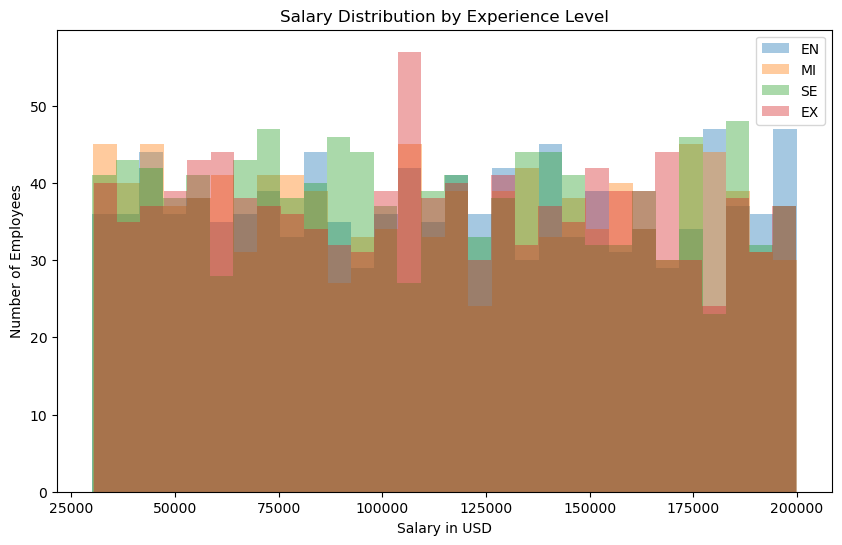

In [37]:
levels = ["EN", "MI", "SE", "EX"]

plt.figure(figsize=(10, 6))

for level in levels:
    salaries = df.loc[
        df["experience_level"] == level,
        "salary_in_usd"
    ]

    plt.hist(
        salaries,
        bins=30,
        alpha=0.4,
        label=level
    )

plt.xlabel("Salary in USD")
plt.ylabel("Number of Employees")
plt.title("Salary Distribution by Experience Level")
plt.legend()
plt.show()

### I Might use KNN to predict the missing 500 values Experience then.

KNN PACKAGES NEEDED

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [39]:
# Rows where experience level is known
train_data = df[df["experience_level"].notna()].copy()

# Rows where experience level is missing
missing_data = df[df["experience_level"].isna()].copy()

In [40]:
X = train_data[["salary_in_usd"]]
y = train_data["experience_level"]

print("Training rows:", len(train_data))
print("Rows to predict:", len(missing_data))

Training rows: 4500
Rows to predict: 500


    This will be the Testing of different K's

In [41]:
for k in [3, 5, 7, 9, 11, 15, 21, 31]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"K={k}: "
        f"Accuracy={scores.mean():.3f} "
        f"(±{scores.std():.3f})"
    )

K=3: Accuracy=0.243 (±0.013)
K=5: Accuracy=0.256 (±0.009)
K=7: Accuracy=0.254 (±0.010)
K=9: Accuracy=0.250 (±0.006)
K=11: Accuracy=0.247 (±0.009)
K=15: Accuracy=0.258 (±0.007)
K=21: Accuracy=0.248 (±0.005)
K=31: Accuracy=0.247 (±0.007)


    Model Training

In [42]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=11,
        weights="distance"
    ))
])

model.fit(X, y)

,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,11
,weights,'distance'
,algorithm,'auto'
,leaf_size,30


PREDICTION TIME!

In [43]:
missing_salary = missing_data[["salary_in_usd"]]

predicted_levels = model.predict(missing_salary)

print("Predicted experience levels:")
print(pd.Series(predicted_levels).value_counts())

Predicted experience levels:
SE    142
MI    126
EN    119
EX    113
Name: count, dtype: int64


In [44]:
missing_predictions = missing_data[
    ["job_title", "job_category", "salary_currency",
     "salary_in_usd", "employee_residence",
     "company_location"]
].copy()

missing_predictions["predicted_experience_level"] = predicted_levels

display(missing_predictions.head(20))

,job_title,job_category,salary_currency,salary_in_usd,employee_residence,company_location,predicted_experience_level
8,Data Analyst,Data Science,EUR,171043,UK,DE,MI
12,Machine Learning Engineer,ML/AI,EUR,76456,MX,DE,SE
23,Statistician,Analysis,JPY,124951,DE,JP,EN
26,Data Scientist,NaN,JPY,147139,DE,JP,SE
29,Data Engineer,Engineering,EUR,174973,DE,DE,SE
33,Machine Learning Engineer,ML/AI,CNY,196759,IN,CN,EN
43,Data Scientist,NaN,INR,100270,US,IN,EN
65,Data Scientist,NaN,EUR,135424,DE,DE,MI
69,Machine Learning Engineer,ML/AI,GBP,70849,MX,UK,EN
79,Machine Learning Engineer,ML/AI,EUR,59018,IN,DE,SE


SALARY RELATION

In [45]:
print(
    missing_predictions
    .groupby("predicted_experience_level")["salary_in_usd"]
    .agg(["count", "mean", "median", "min", "max"])
)

                            count           mean    median    min     max
predicted_experience_level                                               
EN                            119  121310.941176  123766.0  30209  198001
EX                            113  114470.893805  114194.0  30337  199260
MI                            126  120226.492063  131192.5  33413  194354
SE                            142  112415.436620  113843.5  30860  198801


Ok, We will now fill the Missing values thanks to KNN

In [46]:
df.loc[
    df["experience_level"].isna(),
    "experience_level"
] = predicted_levels

In [48]:
# Verification lang
print(df["experience_level"].value_counts(dropna=False))

experience_level
SE    1296
MI    1238
EN    1234
EX    1232
Name: count, dtype: int64


# Saving it for the second time for the actual model training

In [49]:
df.to_csv("data_science_job_clean_v2.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [51]:
df_2

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer,ML/AI,INR,179769,179111,UK,NaN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer,ML/AI,GBP,184642,196373,CN,NaN,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


In [52]:
df

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2022,Machine Learning Engineer,Analysis,EUR,186597,136086,US,MI,CT,Remote,DE,L
1,2020,Statistician,ML/AI,JPY,110630,67982,JP,EX,FL,Remote,IN,M
2,2022,Machine Learning Engineer,ML/AI,INR,61280,153309,UK,MI,CT,Hybrid,CN,L
3,2022,Data Analyst,ML/AI,JPY,154130,135242,DE,SE,FT,Hybrid,MX,L
4,2020,Statistician,Data Science,EUR,172312,35156,UK,MI,FT,In-person,UK,S
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020,Machine Learning Engineer,ML/AI,INR,179769,179111,UK,EN,CT,In-person,IN,NaN
4996,2021,Machine Learning Engineer,ML/AI,GBP,184642,196373,CN,SE,FL,Remote,UK,NaN
4997,2022,Machine Learning Engineer,Analysis,GBP,135319,51366,UK,EN,FL,Hybrid,JP,M
4998,2021,Statistician,Data Science,EUR,58037,181817,US,MI,PT,Remote,DE,S


In [53]:
df.isna().sum()

work_year               0
job_title               0
job_category          101
salary_currency         0
salary                  0
salary_in_usd           0
employee_residence      0
experience_level        0
employment_type         0
work_setting            0
company_location        0
company_size          500
dtype: int64

### Predicting Company size base on the salary-usd it can give

In [54]:
# Salary statistics by company size
company_salary = (
    df[df["company_size"].notna()]
    .groupby("company_size")["salary_in_usd"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print(company_salary)

              count           mean    median           std    min     max
company_size                                                             
L              1464  114895.802596  114494.0  48765.331986  30016  199894
M              1517  113401.736981  112119.0  49184.028166  30178  199985
S              1519  113011.419355  113725.0  49509.749426  30056  199808


In [55]:
company_salary_quartiles = (
    df[df["company_size"].notna()]
    .groupby("company_size")["salary_in_usd"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
)

company_salary_quartiles.columns = ["Q1", "Median", "Q3"]

print(company_salary_quartiles)

                    Q1    Median        Q3
company_size                              
L             72675.75  114494.0  156690.5
M             70831.00  112119.0  156515.0
S             69385.50  113725.0  155775.5


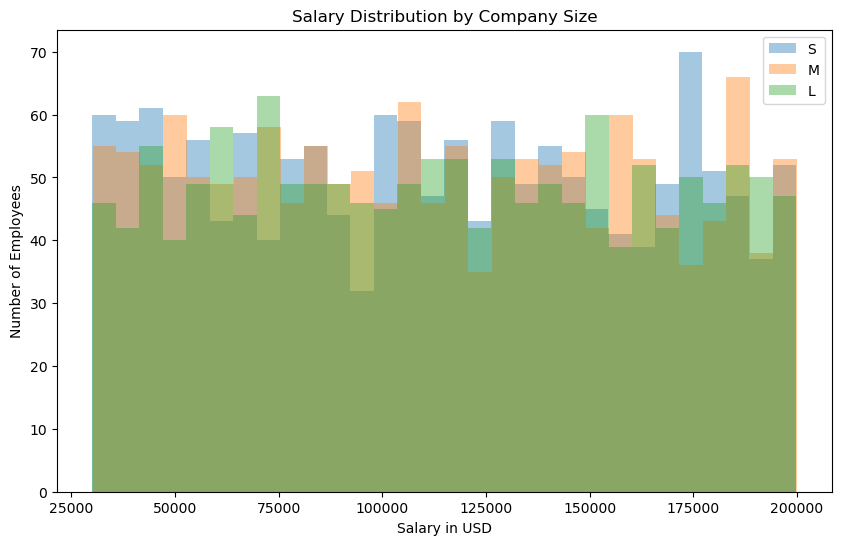

In [56]:
plt.figure(figsize=(10, 6))

for size in ["S", "M", "L"]:
    salaries = df.loc[
        df["company_size"] == size,
        "salary_in_usd"
    ]

    plt.hist(
        salaries,
        bins=30,
        alpha=0.4,
        label=size
    )

plt.xlabel("Salary in USD")
plt.ylabel("Number of Employees")
plt.title("Salary Distribution by Company Size")
plt.legend()
plt.show()

In [57]:
known = df[df["company_size"].notna()].copy()

X = known[["salary_in_usd"]]
y = known["company_size"]

for k in [3, 5, 7, 9, 11, 15, 21]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=k,
            weights="distance"
        ))
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    print(
        f"K={k}: "
        f"Accuracy={scores.mean():.3f} "
        f"(±{scores.std():.3f})"
    )

K=3: Accuracy=0.333 (±0.005)
K=5: Accuracy=0.330 (±0.007)
K=7: Accuracy=0.332 (±0.007)
K=9: Accuracy=0.332 (±0.008)
K=11: Accuracy=0.330 (±0.009)
K=15: Accuracy=0.329 (±0.006)
K=21: Accuracy=0.333 (±0.006)


    salary_in_usd by itself provides almost no predictive information about company_size in this dataset.

So, what i'll do next is something gonna be out of the blue. ill be using
salary_in_usd + job_title + job_category + company_location + employment_type + work_setting + experience_level = company_size

Yeah, heavy math again

In [58]:
print("Missing company_size:")
print(df["company_size"].isna().sum())

print("\nCompany size distribution:")
print(df["company_size"].value_counts(dropna=False))

Missing company_size:
500

Company size distribution:
company_size
S      1519
M      1517
L      1464
NaN     500
Name: count, dtype: int64


In [59]:
features = [
    "salary_in_usd",
    "job_title",
    "job_category",
    "company_location",
    "employment_type",
    "work_setting",
    "experience_level"
]

target = "company_size"

# Rows where company size is known
known = df[df[target].notna()].copy()

print("Rows available for training:", len(known))
print("Missing company size:", df[target].isna().sum())

Rows available for training: 4500
Missing company size: 500


In [60]:
numeric_features = [
    "salary_in_usd"
]

categorical_features = [
    "job_title",
    "job_category",
    "company_location",
    "employment_type",
    "work_setting",
    "experience_level"
]

This will be the packages needed for code pre-processing

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [62]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### We'll be using Random Forest.

In [63]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [65]:
X = known[features]
y = known[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 3600
Testing rows: 900


# Model-Training

In [66]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [68]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.324

Classification Report:
              precision    recall  f1-score   support

           L       0.32      0.32      0.32       293
           M       0.33      0.31      0.32       303
           S       0.33      0.34      0.33       304

    accuracy                           0.32       900
   macro avg       0.32      0.32      0.32       900
weighted avg       0.32      0.32      0.32       900



There is/is not statistically significant evidence that salary differs according to company size.

So, that means I just wasted my time trying to predict something LOL